# Exercise project 1: Linear regression (taxi trip price)
Dataset: Taxi Trip Pricing (Kaggle) link:https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction
Goal: predict `Trip_Price` 

In [67]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv("taxi_trip_pricing.csv")
print(df.shape)
display(df.head())
df.info()
df.describe()

(1000, 11)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [69]:
print("Duplicates:", df.duplicated().sum())
print(df.isnull().sum())

Duplicates: 0
Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64


## Before the work

The dataset has 1000 rows and 11 columns. There are no duplicate rows. The target variable is Trip_Price. The other 10 columns are the support variables.

Continuous columns: Trip_Distance_km, Trip_Duration_Minutes, Base_Fare, Per_Km_Rate, Per_Minute_Rate. Passenger_Count is numeric with small whole values.

Binary: Day_of_Week. Ordinal: Traffic_Conditions. Nominal: Time_of_Day and Weather.

Every column has about 50 missing values, spread over different rows. I will drop the rows where Trip_Price is missing, because the model should not learn from made up answers.

I expect Trip_Distance_km to matter most for the price. I will check this with the correlation matrix later.

Note: I used claude for some codes (checked them by running them and also comparing them with the lecture examples) :)

# Step 1: Clean The data 
Removing the cloums that needs to be filled with unavaiable data, Replace vraibles with the mostcommon value.

In [70]:
df = df.drop_duplicates()
df = df.dropna(subset=['Trip_Price'])

num_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare',
            'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print(df.shape)
print(df.isnull().sum())

(951, 11)
Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


In [71]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# binary
encoder = LabelEncoder()
df[['Day_of_Week']] = df[['Day_of_Week']].apply(encoder.fit_transform)

# ordinal
df['Traffic_Conditions'] = df['Traffic_Conditions'].replace({'Low': 0, 'Medium': 1, 'High': 2})

# nominal
variables = ['Time_of_Day', 'Weather']
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = ohe.fit_transform(df[variables]).astype(int)
df = pd.concat([df, one_hot_encoded], axis=1).drop(columns=variables)
df = df.drop(columns=['Time_of_Day_Night', 'Weather_Snow'])

df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 951 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       951 non-null    float64
 1   Day_of_Week            951 non-null    int64  
 2   Passenger_Count        951 non-null    float64
 3   Traffic_Conditions     951 non-null    object 
 4   Base_Fare              951 non-null    float64
 5   Per_Km_Rate            951 non-null    float64
 6   Per_Minute_Rate        951 non-null    float64
 7   Trip_Duration_Minutes  951 non-null    float64
 8   Trip_Price             951 non-null    float64
 9   Time_of_Day_Afternoon  951 non-null    int64  
 10  Time_of_Day_Evening    951 non-null    int64  
 11  Time_of_Day_Morning    951 non-null    int64  
 12  Weather_Clear          951 non-null    int64  
 13  Weather_Rain           951 non-null    int64  
dtypes: float64(7), int64(6), object(1)
memory usage: 111.4+ KB


,Trip_Distance_km,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Weather_Clear,Weather_Rain
0,19.350000,0,3.0,0,3.56,0.80,0.32,53.82,36.2624,0,0,1,1,0
2,36.870000,1,1.0,2,2.70,1.21,0.15,37.27,52.9032,0,1,0,1,0
3,30.330000,0,4.0,0,3.48,0.51,0.15,116.81,36.4698,0,1,0,1,0
4,27.190998,0,3.0,2,2.93,0.63,0.32,22.64,15.6180,0,1,0,1,0
5,8.640000,1,2.0,1,2.55,1.71,0.48,89.33,60.2028,1,0,0,1,0


# check the balance and looki for outliers by using plot graphs

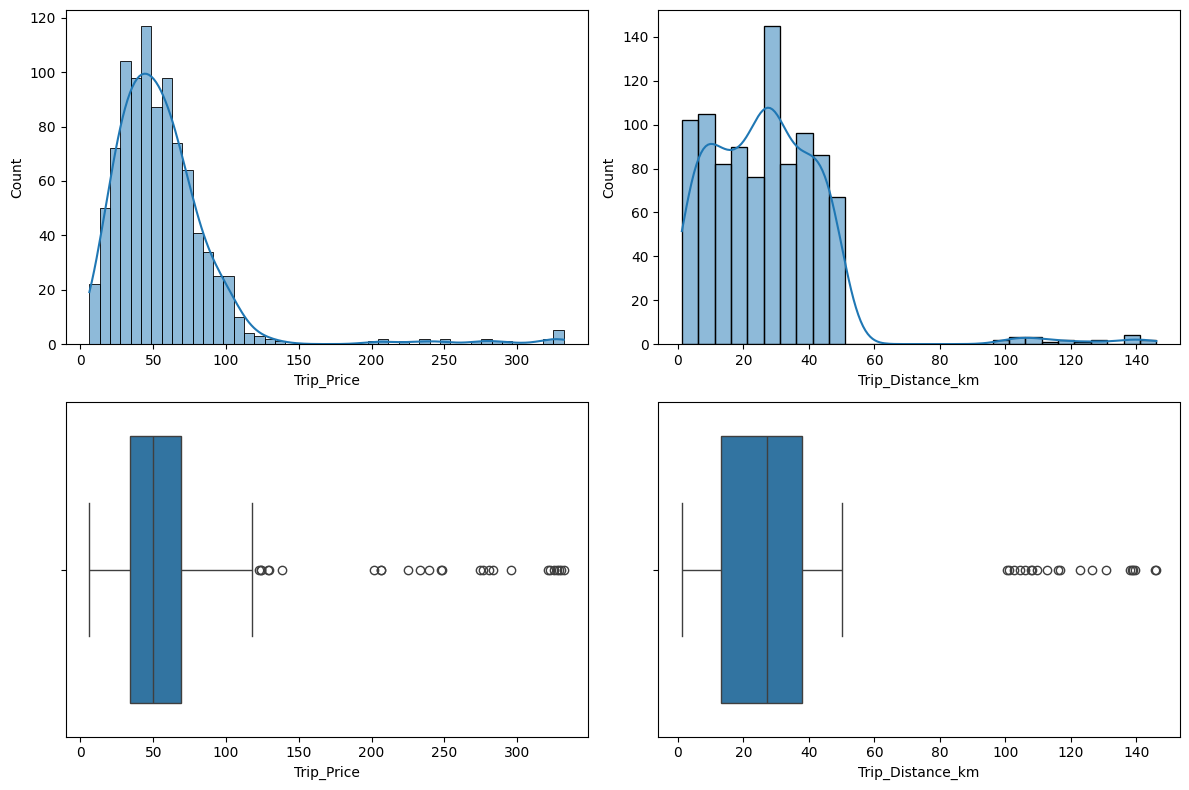

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Trip_Price'], kde=True, ax=axes[0, 0])
sns.histplot(df['Trip_Distance_km'], kde=True, ax=axes[0, 1])
sns.boxplot(x=df['Trip_Price'], ax=axes[1, 0])
sns.boxplot(x=df['Trip_Distance_km'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

Rows before: 951
Rows after: 941


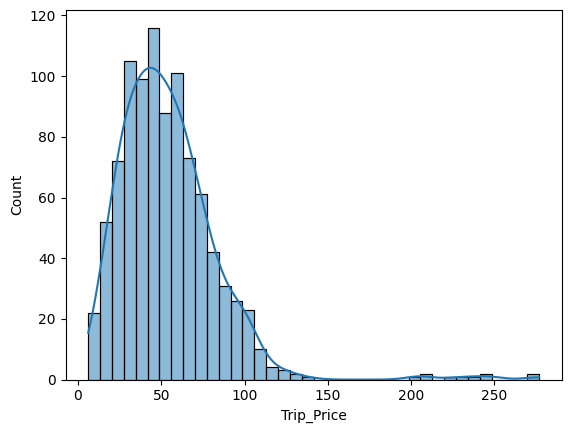

In [73]:
print("Rows before:", len(df))
limit = df['Trip_Price'].quantile(0.99)
df = df[df['Trip_Price'] <= limit]
print("Rows after:", len(df))

sns.histplot(df['Trip_Price'], kde=True)
plt.show()

In [74]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Trip_Price'])
y = df['Trip_Price']

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

print(train_x.shape, test_x.shape)

(752, 13) (189, 13)


## Step 2 and 3 analysis

The price data was skewed to the right with a few very expensive trips. I removed the top 1 percent of prices as outliers. After this the histogram looks more like a normal distribution.

I used an 80/20 split: 80 percent for training and 20 percent for testing. train_x and train_y are for training, test_x and test_y are for checking the model later.

In [75]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_x, train_y)

predictions = model.predict(test_x)

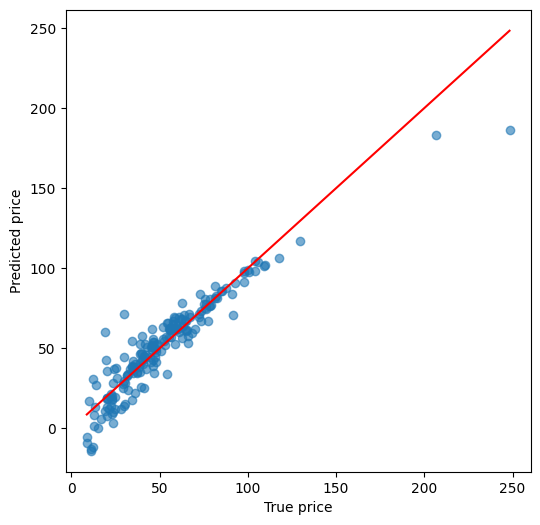

In [76]:
plt.figure(figsize=(6, 6))
plt.scatter(test_y, predictions, alpha=0.6)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red')
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.show()

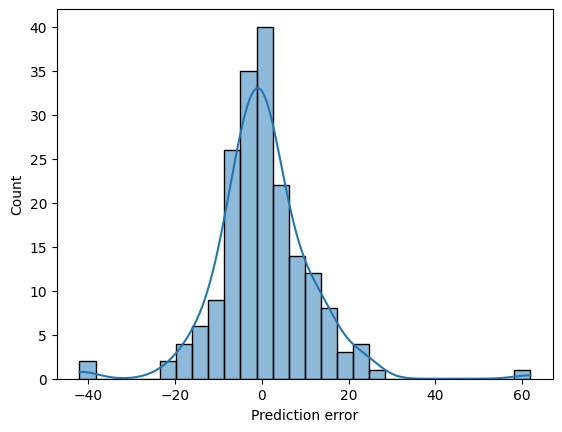

In [77]:
errors = test_y - predictions
sns.histplot(errors, kde=True)
plt.xlabel("Prediction error")
plt.show()

## Step 4 analysis

Most points follow the red line, so the model follows a linear trend. Two very expensive trips are predicted too low, and some cheap trips get a negative price. The error histogram is a bell shape around 0, with a few big errors.

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test_y, predictions)
mse = mean_squared_error(test_y, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 7.3961945812991
MSE: 116.98623634215434
RMSE: 10.816017582370803
R-squared: 0.8763362034071923


In [79]:
train_predictions = model.predict(train_x)
train_rmse = np.sqrt(mean_squared_error(train_y, train_predictions))

print("Train RMSE:", train_rmse)
print("Test RMSE:", rmse)

Train RMSE: 10.957507684206451
Test RMSE: 10.816017582370803


# Step 5 analysis

MAE is 7.40. On average the prediction is about 7.40 off.
MSE is 116.99. RMSE is 10.82, in the same unit as the price.
R-squared is 0.88. The model explains about 88 percent of the price.
Train RMSE is 10.96 and test RMSE is 10.82. They are close, so no overfitting.
The average price is about 54, so an error of about 11 is medium. Good for most trips, but not very exact.

# step 6 correlation matrix 

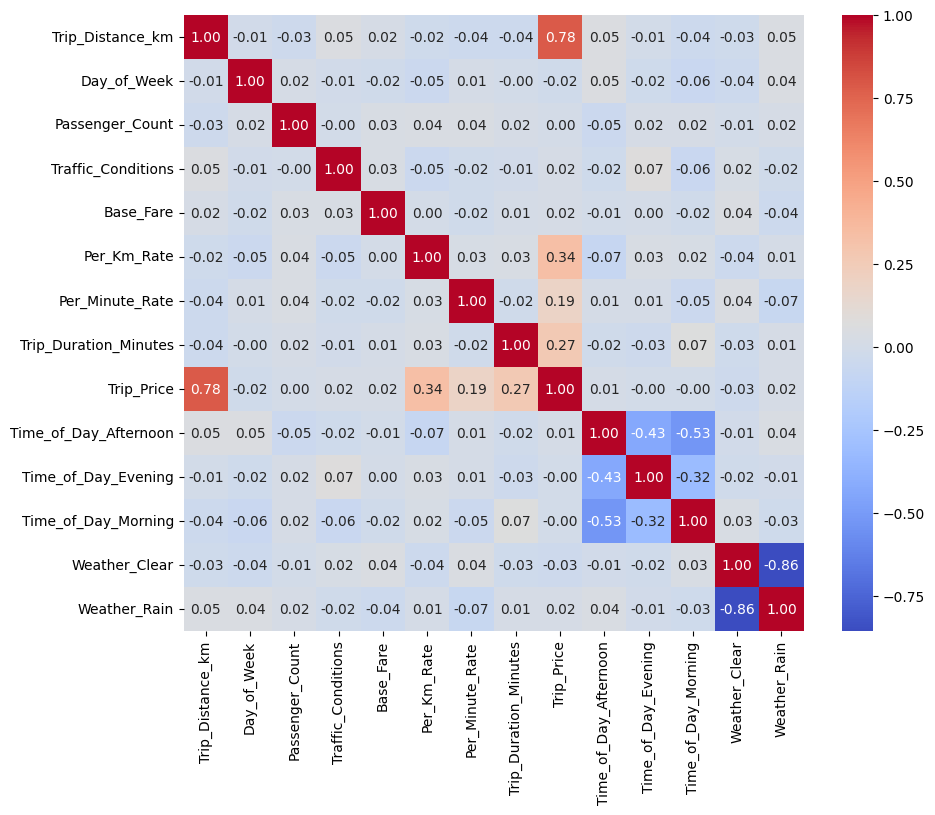

Weather_Clear           -0.032109
Day_of_Week             -0.018966
Time_of_Day_Morning     -0.004535
Time_of_Day_Evening     -0.001842
Passenger_Count          0.004642
Time_of_Day_Afternoon    0.011605
Weather_Rain             0.017808
Base_Fare                0.018864
Traffic_Conditions       0.018928
Per_Minute_Rate          0.185268
Trip_Duration_Minutes    0.267503
Per_Km_Rate              0.339607
Trip_Distance_km         0.783082
Trip_Price               1.000000
Name: Trip_Price, dtype: float64

In [80]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

df.corr()['Trip_Price'].sort_values()

# Testing 

In [81]:
short_trip = {
    'Trip_Distance_km': 5, 'Day_of_Week': 0, 'Passenger_Count': 1,
    'Traffic_Conditions': 0, 'Base_Fare': 3.5, 'Per_Km_Rate': 1.2,
    'Per_Minute_Rate': 0.3, 'Trip_Duration_Minutes': 15,
    'Time_of_Day_Afternoon': 1, 'Time_of_Day_Evening': 0, 'Time_of_Day_Morning': 0,
    'Weather_Clear': 1, 'Weather_Rain': 0
}

long_trip = short_trip.copy()
long_trip['Trip_Distance_km'] = 50
long_trip['Trip_Duration_Minutes'] = 70

tester = pd.DataFrame([short_trip, long_trip])[train_x.columns]
print(model.predict(tester))

[ 9.24084282 91.42524643]


Note: I used claude & Gemini alongside the code examples in moodle from the lectures for the testing cod as i stayed for more than 20 mins and could not figure it out alone :)

In [82]:
heavy_traffic = long_trip.copy()
heavy_traffic['Traffic_Conditions'] = 2

tester2 = pd.DataFrame([long_trip, heavy_traffic])[train_x.columns]
print(model.predict(tester2))

[91.42524643 91.05434607]


# copied the code from the lecttures examples

# Step 6 analysis

The strongest correlation with Trip_Price is Trip_Distance_km (0.78). The other columns are weak.

The 5 km trip was predicted at 9.24 and the 50 km trip at 91.43. Longer trips cost more, which makes sense.

High traffic changed the price by only -0.37. Traffic has almost no effect in this model.

# Final analysis

How the code works: I cleaned the data, changed the text columns to numbers, and split it into train and test. Then I trained LinearRegression with fit() and checked the errors on the test data.

Results: R-squared is 0.88 and RMSE is 10.82. The model works well. Train RMSE and test RMSE are close, so no overfitting.

Where it is useful: price estimation, like taxi fares, house prices or delivery costs.

Medium or hard: The model code was medium because scikit-learn does the math, but I had to understand the steps. I met many bugs. Cleaning and encoding the data took the most time.

Ideas to improve: remove more outliers, add a new feature like distance times rate, or try a polynomial model.